# 不同 degree × lambda 下 CD_A / CD_B / CD_BOmega / GOLEM 对比

在随机 ER 图上，测试不同图稀疏度 (degree) 与正则化强度 (lambda_l0) 对三种坐标下降算法 (noepoch 版本) 和 GOLEM 的影响。

In [3]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_A
from coordinate_descent.cd_B import dag_coordinate_descent_B as cd_B
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega as cd_BOmega

# GOLEM
GOLEM_SRC = os.path.join(repo_root, 'golemMain', 'src')
if GOLEM_SRC not in sys.path:
    sys.path.append(GOLEM_SRC)
try:
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM loaded.')
except Exception as e:
    HAS_GOLEM = False
    warnings.warn(f'GOLEM not available: {e}')
    print(f'GOLEM not available: {e}')

GOLEM loaded.


In [4]:
def weight_to_binary_adj(W, threshold=0.05):
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G

def shd_score(G_true, G_est):
    return int(np.sum(np.abs(G_true - G_est)))

def cpdag_shd_score(G_true, G_est):
    skel_true, skel_est = get_skeleton(G_true), get_skeleton(G_est)
    skeleton_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skeleton_diff + v_diff)

def precision_recall_f1(G_true, G_est):
    te, pe = (G_true == 1), (G_est == 1)
    tp = int(np.sum(te & pe))
    fp = int(np.sum((~te) & pe))
    fn = int(np.sum(te & (~pe)))
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return prec, rec, f1

def make_row(degree, lam, trial, seed, alg, runtime, G_true, G_est):
    p, r, f1 = precision_recall_f1(G_true, G_est)
    return {
        'degree': degree, 'lambda': lam, 'trial': trial, 'seed': seed,
        'algorithm': alg, 'runtime_sec': runtime,
        'shd': shd_score(G_true, G_est),
        'cpdag_shd': cpdag_shd_score(G_true, G_est),
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
        'precision': p, 'recall': r, 'f1': f1,
        'n_edges_true': int(G_true.sum()),
        'n_edges_est': int(G_est.sum()),
    }

In [5]:
CFG = {
    'trials': 10,
    'seed': 42,
    'd': 30,
    'n': 30000,
    'B_scale': 1.0,
    'noise_type': 'gaussian_ev',
    'threshold': 0.05,
    'degree_list': [1, 2, 3, 4],
    'lambda_list': [0.0, 0.05, 0.1, 0.2, 0.3],
    # noepoch 版本用 T (迭代步数)
    'T': 100000,
    # GOLEM 默认配置 (GOLEM-NV)
    'golem_lambda1': 2e-3,
    'golem_lambda2': 5.0,
    'golem_equal_variances': False,
    'golem_num_iter': 100000,
    'golem_lr': 1e-3,
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag': 'degree_lambda_benchmark',
}
os.makedirs(CFG['out_dir'], exist_ok=True)
print('Config ready.')

Config ready.


In [6]:
rows = []
rng = np.random.default_rng(CFG['seed'])
d, n = CFG['d'], CFG['n']
T = CFG['T']
th = CFG['threshold']

for deg in CFG['degree_list']:
    seeds = rng.integers(0, 10**9, size=CFG['trials'])
    for trial_idx, seed in enumerate(seeds, start=1):
        seed = int(seed)
        dataset = SyntheticDataset(
            n=n, d=d, graph_type='ER', degree=deg,
            noise_type=CFG['noise_type'], B_scale=CFG['B_scale'], seed=seed,
        )
        X = dataset.X
        S = X.T @ X / n
        G_true = weight_to_binary_adj(dataset.B, threshold=0.0)

        for lam in CFG['lambda_list']:
            # --- CD_A (noepoch) ---
            t0 = time.perf_counter()
            A_est, G_A, _ = cd_A(S=S, T=T, seed=seed, threshold=th, lambda_l0=lam)
            rt = time.perf_counter() - t0
            rows.append(make_row(deg, lam, trial_idx, seed, 'CD_A', rt, G_true, G_A))

            # --- CD_B (noepoch) ---
            t0 = time.perf_counter()
            B_est, G_B, _, _ = cd_B(S=S, T=T, seed=seed, threshold=th, lambda_l0=lam)
            rt = time.perf_counter() - t0
            rows.append(make_row(deg, lam, trial_idx, seed, 'CD_B', rt, G_true, G_B))

            # --- CD_BOmega (noepoch) ---
            t0 = time.perf_counter()
            Bo_est, G_BO, _, _ = cd_BOmega(
                S=S, Omega=np.eye(d), T=T, seed=seed, threshold=th, lambda_l0=lam,
            )
            rt = time.perf_counter() - t0
            rows.append(make_row(deg, lam, trial_idx, seed, 'CD_BOmega', rt, G_true, G_BO))

        # --- GOLEM (lambda 不适用，固定配置跑一次) ---
        if HAS_GOLEM:
            t0 = time.perf_counter()
            B_golem = golem_fit(
                X, lambda_1=CFG['golem_lambda1'], lambda_2=CFG['golem_lambda2'],
                equal_variances=CFG['golem_equal_variances'],
                num_iter=CFG['golem_num_iter'], learning_rate=CFG['golem_lr'], seed=seed,
            )
            rt = time.perf_counter() - t0
            G_golem = weight_to_binary_adj(B_golem, threshold=0.3)
            rows.append(make_row(deg, np.nan, trial_idx, seed, 'GOLEM', rt, G_true, G_golem))

        shd_last = rows[-1]['shd']
        print(f'degree={deg}  trial {trial_idx}/{CFG["trials"]}  last_shd={shd_last}')

df = pd.DataFrame(rows)
print(f'\nDone. {len(df)} rows collected.')


degree=1  trial 1/10  last_shd=31
degree=1  trial 2/10  last_shd=32
degree=1  trial 3/10  last_shd=25
degree=1  trial 4/10  last_shd=44
degree=1  trial 5/10  last_shd=30
degree=1  trial 6/10  last_shd=13
degree=1  trial 7/10  last_shd=33
degree=1  trial 8/10  last_shd=26
degree=1  trial 9/10  last_shd=32
degree=1  trial 10/10  last_shd=29
degree=2  trial 1/10  last_shd=59
degree=2  trial 2/10  last_shd=43
degree=2  trial 3/10  last_shd=68
degree=2  trial 4/10  last_shd=51
degree=2  trial 5/10  last_shd=54
degree=2  trial 6/10  last_shd=57
degree=2  trial 7/10  last_shd=48
degree=2  trial 8/10  last_shd=65
degree=2  trial 9/10  last_shd=56
degree=2  trial 10/10  last_shd=44
degree=3  trial 1/10  last_shd=72
degree=3  trial 2/10  last_shd=72
degree=3  trial 3/10  last_shd=71
degree=3  trial 4/10  last_shd=73
degree=3  trial 5/10  last_shd=80
degree=3  trial 6/10  last_shd=82
degree=3  trial 7/10  last_shd=80
degree=3  trial 8/10  last_shd=86
degree=3  trial 9/10  last_shd=70
degree=3  t

## 汇总统计

In [7]:
summary = df.groupby(['degree', 'lambda', 'algorithm']).agg(
    shd_mean=('shd', 'mean'), shd_std=('shd', 'std'),
    cpdag_shd_mean=('cpdag_shd', 'mean'),
    mec_rate=('mec_match', 'mean'),
    f1_mean=('f1', 'mean'),
    runtime_mean=('runtime_sec', 'mean'),
).reset_index()

with pd.option_context('display.max_rows', 200, 'display.float_format', '{:.3f}'.format):
    display(summary)

df.to_csv(os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv"), index=False)
summary.to_csv(os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv"), index=False)
print('Results saved.')

,degree,lambda,algorithm,shd_mean,shd_std,cpdag_shd_mean,mec_rate,f1_mean,runtime_mean
0,1,0.000,CD_A,7.500,7.976,6.600,0.100,0.798,76.595
1,1,0.000,CD_B,18.200,6.443,11.600,0.000,0.492,84.054
2,1,0.000,CD_BOmega,18.700,9.429,11.500,0.000,0.503,95.011
3,1,0.050,CD_A,7.600,4.766,4.800,0.100,0.773,43.145
4,1,0.050,CD_B,7.700,8.820,9.100,0.400,0.815,50.540
5,1,0.050,CD_BOmega,9.300,8.654,9.800,0.200,0.745,63.699
6,1,0.100,CD_A,7.400,3.777,5.100,0.200,0.770,43.346
7,1,0.100,CD_B,7.900,8.144,8.000,0.300,0.795,50.864
8,1,0.100,CD_BOmega,7.000,6.000,9.300,0.100,0.798,63.569
9,1,0.200,CD_A,6.500,5.255,4.900,0.300,0.803,43.383


Results saved.


## SHD vs lambda（按 degree 分面，各算法对比）

In [1]:
cd_algs = ['CD_A', 'CD_B', 'CD_BOmega']
colors = {'CD_A': 'tab:blue', 'CD_B': 'tab:green', 'CD_BOmega': 'tab:orange', 'GOLEM': 'tab:red'}
markers = {'CD_A': 'o', 'CD_B': 's', 'CD_BOmega': '^', 'GOLEM': 'D'}

degrees = sorted(df['degree'].unique())
fig, axes = plt.subplots(1, len(degrees), figsize=(5 * len(degrees), 9), squeeze=False)

for col_idx, deg in enumerate(degrees):
    # --- SHD vs lambda ---
    ax = axes[0, col_idx]
    for alg in cd_algs:
        sub = summary[(summary['degree'] == deg) & (summary['algorithm'] == alg)]
        ax.errorbar(sub['lambda'], sub['shd_mean'], yerr=sub['shd_std'],
                    marker=markers[alg], color=colors[alg], capsize=3, label=alg)
    # GOLEM 水平线
    golem_sub = summary[(summary['degree'] == deg) & (summary['algorithm'] == 'GOLEM')]
    if len(golem_sub):
        golem_shd = golem_sub['shd_mean'].values[0]
        ax.axhline(golem_shd, color=colors['GOLEM'], ls='--', lw=1.5, label='GOLEM')
    ax.set_title(f'degree={deg}')
    ax.set_xlabel('lambda_l0')
    if col_idx == 0:
        ax.set_ylabel('SHD (mean ± std)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # # --- F1 vs lambda ---
    # ax = axes[1, col_idx]
    # for alg in cd_algs:
    #     sub = summary[(summary['degree'] == deg) & (summary['algorithm'] == alg)]
    #     ax.plot(sub['lambda'], sub['f1_mean'], marker=markers[alg], color=colors[alg], label=alg)
    # if len(golem_sub):
    #     golem_f1 = golem_sub['f1_mean'].values[0]
    #     ax.axhline(golem_f1, color=colors['GOLEM'], ls='--', lw=1.5, label='GOLEM')
    # ax.set_title(f'degree={deg}')
    # ax.set_xlabel('lambda_l0')
    # if col_idx == 0:
    #     ax.set_ylabel('F1 (mean)')
    # ax.set_ylim(-0.05, 1.05)
    # ax.legend(fontsize=7)
    # ax.grid(True, alpha=0.3)

plt.suptitle('SHD & F1 vs lambda_l0 (按 degree 分面)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], f"{CFG['tag']}_shd_f1_vs_lambda.png"), dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'df' is not defined

## MEC match rate 热力图

KeyError: 'mec_rate'

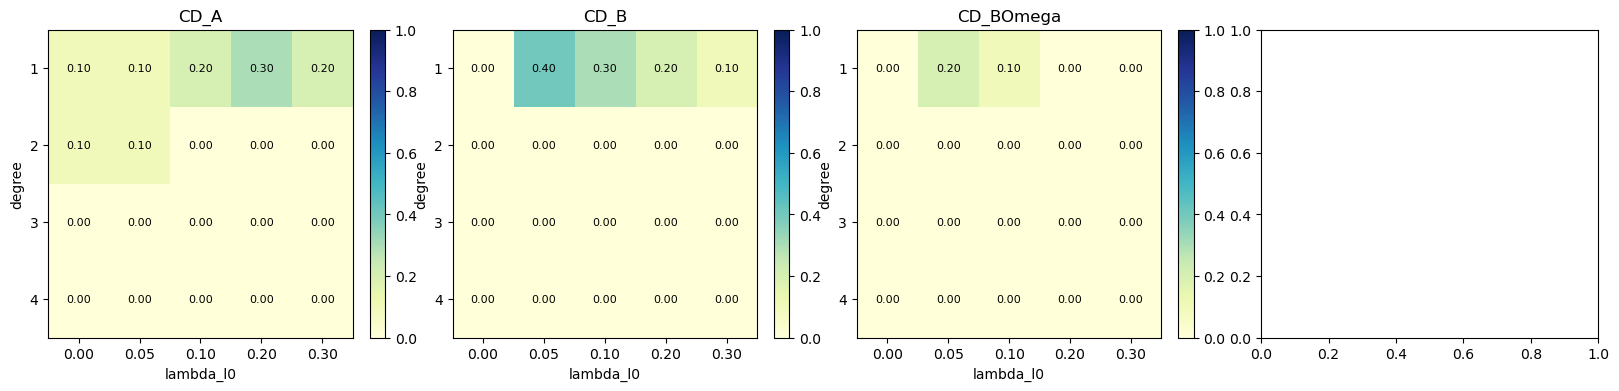

In [9]:
all_algs = cd_algs + (['GOLEM'] if HAS_GOLEM else [])
fig, axes = plt.subplots(1, len(all_algs), figsize=(5 * len(all_algs), 4), squeeze=False)

for idx, alg in enumerate(all_algs):
    ax = axes[0, idx]
    sub = summary[summary['algorithm'] == alg]
    if alg == 'GOLEM':
        # GOLEM 只有 degree 维度，lambda 为 NaN
        pivot = sub.pivot_table(index='degree', values='mec_rate', aggfunc='mean')
        ax.barh(pivot.index.astype(str), pivot['mec_rate'], color=colors[alg])
        ax.set_xlabel('MEC match rate')
        ax.set_ylabel('degree')
        ax.set_xlim(0, 1)
    else:
        pivot = sub.pivot_table(index='degree', columns='lambda', values='mec_rate')
        im = ax.imshow(pivot.values, aspect='auto', vmin=0, vmax=1, cmap='YlGnBu')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('lambda_l0')
        ax.set_ylabel('degree')
        for r in range(pivot.shape[0]):
            for c in range(pivot.shape[1]):
                ax.text(c, r, f'{pivot.values[r, c]:.2f}', ha='center', va='center', fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(alg)

plt.suptitle('MEC Match Rate', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], f"{CFG['tag']}_mec_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

## SHD 热力图（degree × lambda，每个算法一张）

In [ ]:
fig, axes = plt.subplots(1, len(cd_algs), figsize=(5 * len(cd_algs), 4), squeeze=False)

vmax = summary[summary['algorithm'].isin(cd_algs)]['shd_mean'].max()

for idx, alg in enumerate(cd_algs):
    ax = axes[0, idx]
    sub = summary[summary['algorithm'] == alg]
    pivot = sub.pivot_table(index='degree', columns='lambda', values='shd_mean')
    im = ax.imshow(pivot.values, aspect='auto', vmin=0, vmax=vmax, cmap='OrRd')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('lambda_l0')
    ax.set_ylabel('degree')
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            ax.text(c, r, f'{pivot.values[r, c]:.1f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'{alg} — mean SHD')

plt.suptitle('SHD Heatmap (degree × lambda)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], f"{CFG['tag']}_shd_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

## 运行时间对比

In [ ]:
# 取每个算法在各 degree 下的平均运行时间（CD 算法取所有 lambda 的均值）
rt = df.groupby(['degree', 'algorithm'])['runtime_sec'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for alg in all_algs:
    sub = rt[rt['algorithm'] == alg]
    ax.plot(sub['degree'], sub['runtime_sec'], marker=markers[alg], color=colors[alg], label=alg, lw=2)
ax.set_xlabel('degree')
ax.set_ylabel('Runtime (sec, mean)')
ax.set_title('平均运行时间 vs degree')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], f"{CFG['tag']}_runtime.png"), dpi=150)
plt.show()

## 各算法最优 lambda 下的 SHD 对比（含 GOLEM）

In [ ]:
# 对每个 (degree, algorithm)，选最优 lambda（最小 shd_mean）
best_rows = []
for deg in degrees:
    for alg in all_algs:
        sub = summary[(summary['degree'] == deg) & (summary['algorithm'] == alg)]
        if len(sub) == 0:
            continue
        best = sub.loc[sub['shd_mean'].idxmin()]
        best_rows.append(best)

best_df = pd.DataFrame(best_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Best SHD ---
ax = axes[0]
x = np.arange(len(degrees))
width = 0.18
for i, alg in enumerate(all_algs):
    sub = best_df[best_df['algorithm'] == alg]
    vals = [sub[sub['degree'] == deg]['shd_mean'].values[0] if len(sub[sub['degree'] == deg]) else 0 for deg in degrees]
    ax.bar(x + i * width, vals, width, label=alg, color=colors[alg])
ax.set_xticks(x + width * (len(all_algs) - 1) / 2)
ax.set_xticklabels([f'd={deg}' for deg in degrees])
ax.set_ylabel('SHD (mean, best lambda)')
ax.set_title('各算法最优 lambda 下 SHD')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# --- Best F1 ---
ax = axes[1]
for i, alg in enumerate(all_algs):
    sub = best_df[best_df['algorithm'] == alg]
    vals = [sub[sub['degree'] == deg]['f1_mean'].values[0] if len(sub[sub['degree'] == deg]) else 0 for deg in degrees]
    ax.bar(x + i * width, vals, width, label=alg, color=colors[alg])
ax.set_xticks(x + width * (len(all_algs) - 1) / 2)
ax.set_xticklabels([f'd={deg}' for deg in degrees])
ax.set_ylabel('F1 (mean, best lambda)')
ax.set_title('各算法最优 lambda 下 F1')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], f"{CFG['tag']}_best_lambda.png"), dpi=150)
plt.show()

# 打印最优 lambda 选择
print('\n最优 lambda 选择:')
print(best_df[['degree', 'algorithm', 'lambda', 'shd_mean', 'f1_mean', 'mec_rate']].to_string(index=False))

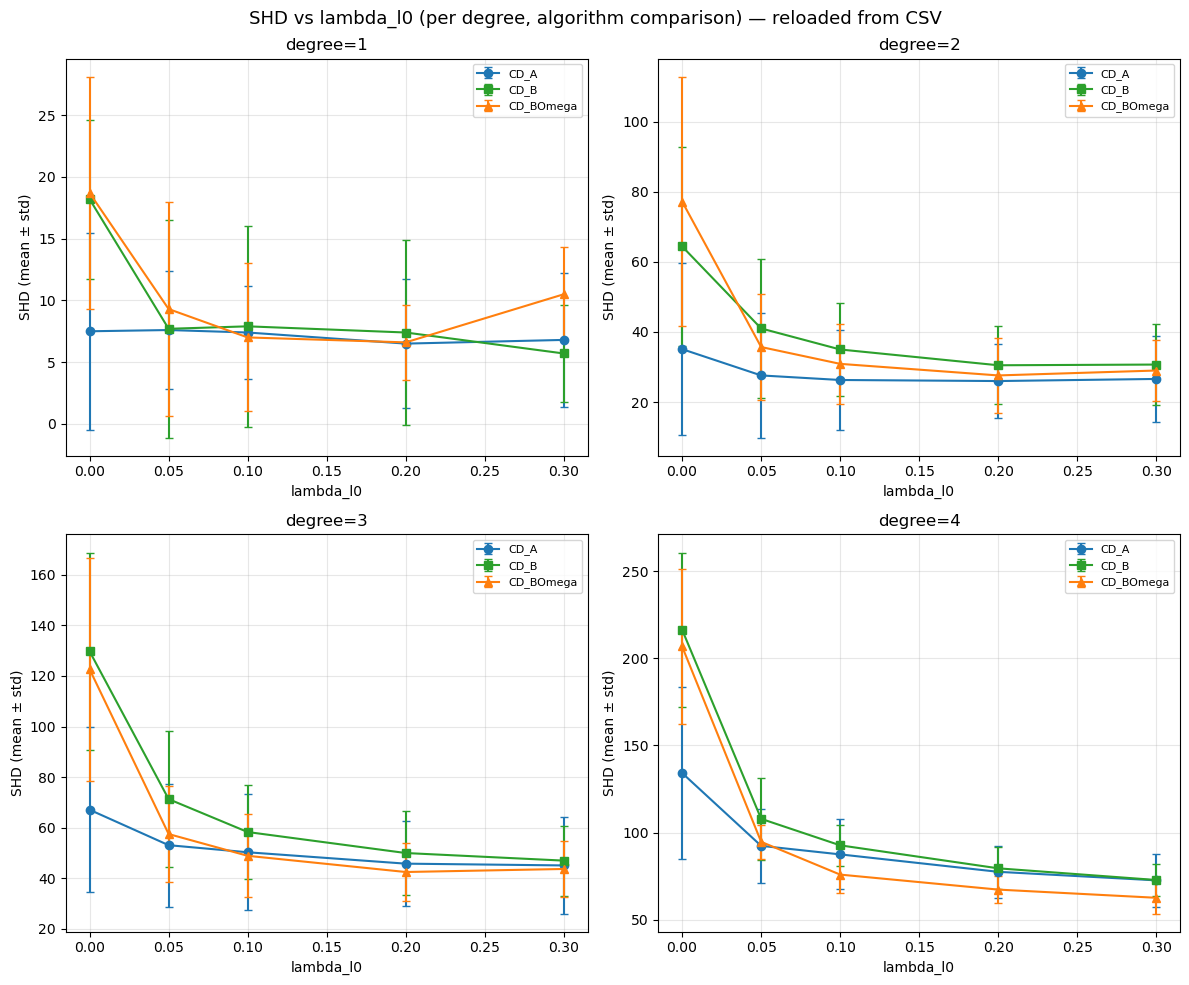

In [3]:
# ---- 从已保存的 CSV 重新加载数据并画 SHD vs lambda（按 degree 分面，各算法对比）----
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path(r'C:\Users\super\DAG\experiments\results')
tag = 'degree_lambda_benchmark'

df = pd.read_csv(out_dir / f'{tag}_trials.csv')
summary = pd.read_csv(out_dir / f'{tag}_summary.csv')

colors = {'CD_A': 'tab:blue', 'CD_B': 'tab:green', 'CD_BOmega': 'tab:orange', 'GOLEM': 'tab:red'}
markers = {'CD_A': 'o', 'CD_B': 's', 'CD_BOmega': '^', 'GOLEM': 'D'}
cd_algs = [a for a in ['CD_A', 'CD_B', 'CD_BOmega'] if a in summary['algorithm'].unique()]
has_golem = 'GOLEM' in summary['algorithm'].unique()

degrees = sorted(summary['degree'].unique())
nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10), squeeze=False)

for idx, deg in enumerate(degrees):
    ax = axes[idx // ncols, idx % ncols]
    for alg in cd_algs:
        sub = summary[(summary['degree'] == deg) & (summary['algorithm'] == alg)]
        ax.errorbar(sub['lambda'], sub['shd_mean'], yerr=sub['shd_std'],
                    marker=markers[alg], color=colors[alg], capsize=3, label=alg)
    # GOLEM 水平线
    if has_golem:
        golem_sub = summary[(summary['degree'] == deg) & (summary['algorithm'] == 'GOLEM')]
        if len(golem_sub):
            golem_shd = golem_sub['shd_mean'].values[0]
            ax.axhline(golem_shd, color=colors['GOLEM'], ls='--', lw=1.5, label='GOLEM')
    ax.set_title(f'degree={deg}')
    ax.set_xlabel('lambda_l0')
    ax.set_ylabel('SHD (mean ± std)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# 隐藏多余的子图
for idx in range(len(degrees), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis('off')

plt.suptitle('SHD vs lambda_l0 (per degree, algorithm comparison) — reloaded from CSV', fontsize=13)
plt.tight_layout()
plt.show()